# SimFormer: every conditional from one model

A normal diffusion model learns one distribution. If you train it on a joint $p(x_0, x_1)$
you can sample the joint, but $p(x_1 \mid x_0)$ needs either guidance tricks or a second
model trained for that specific split.

SimFormer removes the choice. The trick is to stop treating the sample as a vector and
start treating it as a **set of tokens**, one per variable, each tagged with

- which variable it is (a node embedding), and
- whether it is currently *observed* or *latent* (a condition embedding).

Then train with a randomly drawn condition mask on every batch. The model sees every
observation pattern during training, so at sampling time you pick the pattern you want.
The denoiser is a `Transformer`, which is what makes the variables able to talk to each
other regardless of which are observed.

Here: one model on a 2-D checkerboard, then the joint and both conditionals from it.

In [1]:
from functools import partial

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from flax import nnx

from data import CheckerboardGenerator
from probjax.nn import EDM, GaussianFourierEmbedding, Transformer

NUM_NODES = 2

generator = CheckerboardGenerator(grid_size=3, scale=4.0)
data = generator.generate(4000, key=jax.random.key(0))[:, :, None]  # (batch, node, 1)
print("data:", data.shape, " (one token per variable)")

data: (4000, 2, 1)  (one token per variable)


## The denoiser

`EDM` calls its network as `net(c_t(t), c_in(t) * x_t, *args)` and forwards any extra
arguments untouched — so the condition mask and the observed values ride along beside the
noisy sample.

Inside, three embeddings are summed into each token, and the noise level enters as the
transformer's `context` (FiLM conditioning, the same path `TimeMLP` uses):

In [2]:
class SimformerNet(nnx.Module):
    def __init__(self, dim, rngs):
        self.value_embed = nnx.Linear(1, dim, rngs=rngs)
        self.node_embed = nnx.Embed(NUM_NODES, dim, rngs=rngs)      # which variable
        self.cond_embed = nnx.Embed(2, dim, rngs=rngs)              # observed or latent
        self.time_embed = GaussianFourierEmbedding(1, dim, rngs=rngs)
        self.body = Transformer(
            dim, num_heads=4, num_layers=3, attn_size=16, context_dim=dim, rngs=rngs
        )
        self.head = nnx.Linear(dim, 1, rngs=rngs)

    def __call__(self, t_embed, x_scaled, condition_mask, x_observed, rng=None):
        # Observed tokens carry the clean value; latent tokens carry the noisy one.
        values = jnp.where(condition_mask[..., None], x_observed, x_scaled)
        tokens = (
            self.value_embed(values)
            + self.node_embed(jnp.arange(NUM_NODES))[None]
            + self.cond_embed(condition_mask.astype(jnp.int32))
        )
        noise_level = self.time_embed(jnp.atleast_2d(t_embed.reshape(-1, 1)))
        return self.head(self.body(tokens, context=noise_level))


model = EDM(SimformerNet(64, nnx.Rngs(0)), num_steps=64)

## Training with random condition masks

`model.loss` forwards `loss_mask` down to the denoising loss, and the convention there is
**`loss_mask=True` means "exclude"**. Excluded tokens are also left un-noised — which is
exactly the semantics an observed variable needs, from a single argument:

- observed tokens keep their clean value and contribute nothing to the loss;
- latent tokens are noised and are the only thing the model is scored on.

Drawing a fresh mask per example each step is the whole training-time difference from an
ordinary diffusion model. The all-observed mask is dropped, since it would leave nothing
to predict.

In [3]:
optimizer = nnx.Optimizer(model, optax.adamw(1e-3), wrt=nnx.Param)


@nnx.jit
def train_step(model, optimizer, rng, batch):
    rng_mask, rng_loss = jax.random.split(rng)
    condition_mask = jax.random.bernoulli(rng_mask, 0.35, (batch.shape[0], NUM_NODES))
    condition_mask &= ~jnp.all(condition_mask, axis=-1, keepdims=True)

    def loss_fn(m):
        # args after `data` are forwarded to the net; loss_mask=True -> exclude.
        return m.loss(rng_loss, batch, condition_mask, batch,
                      loss_mask=condition_mask[..., None])

    loss, grads = nnx.value_and_grad(loss_fn)(model)
    optimizer.update(model, grads)
    return loss


key = jax.random.key(1)
losses = []
for step in range(6000):
    key, key_batch, key_step = jax.random.split(key, 3)
    idx = jax.random.randint(key_batch, (256,), 0, data.shape[0])
    losses.append(float(train_step(model, optimizer, key_step, data[idx])))

losses = jnp.array(losses)
print(f"loss {float(losses[:200].mean()):.3f} -> {float(losses[-200:].mean()):.3f} (smoothed)")

loss 2.240 -> 1.879 (smoothed)


## Sampling any conditional

The reverse process is the EDM deterministic sampler: step down the Karras noise schedule
and, at each step, move $x$ along $(x - D(\sigma, x))/\sigma$.

The only addition is one line — **observed tokens are reset to their values after every
step**. They never diffuse; they are the boundary condition the latent tokens are solved
against.

The condition mask is a plain argument, so *the same trained weights* answer every query.

In [4]:
T_MIN, T_MAX, RHO = 2e-4, 80.0, 7.0


def karras_sigmas(num_steps):
    ramp = jnp.arange(num_steps) / (num_steps - 1)
    lo, hi = T_MIN ** (1 / RHO), T_MAX ** (1 / RHO)
    return jnp.concatenate([(hi + ramp * (lo - hi)) ** RHO, jnp.zeros(1)])


@partial(nnx.jit, static_argnums=(4, 5))
def sample(model, rng, condition_mask, x_observed, num_samples, num_steps=64):
    sigmas = karras_sigmas(num_steps)
    mask = jnp.broadcast_to(condition_mask, (num_samples, NUM_NODES))[..., None]
    observed = jnp.broadcast_to(x_observed, (num_samples, NUM_NODES, 1))

    x = jax.random.normal(rng, (num_samples, NUM_NODES, 1)) * sigmas[0]

    def step(i, x):
        sigma, sigma_next = sigmas[i], sigmas[i + 1]
        denoised = model.denoise(
            jnp.full((num_samples, 1, 1), sigma), x, mask[..., 0], observed
        )
        x = x + (x - denoised) / sigma * (sigma_next - sigma)
        return jnp.where(mask, observed, x)  # observed tokens never move

    return jax.lax.fori_loop(0, num_steps, step, jnp.where(mask, observed, x))


nothing_observed = jnp.zeros(NUM_NODES, bool)
joint = sample(model, jax.random.key(0), nothing_observed, jnp.zeros((NUM_NODES, 1)), 2000)
print("joint std:", jnp.round(joint.std((0, 2)), 2), " data std:", jnp.round(data.std((0, 2)), 2))

joint std: [2.72 2.69]  data std: [2.53 2.51]


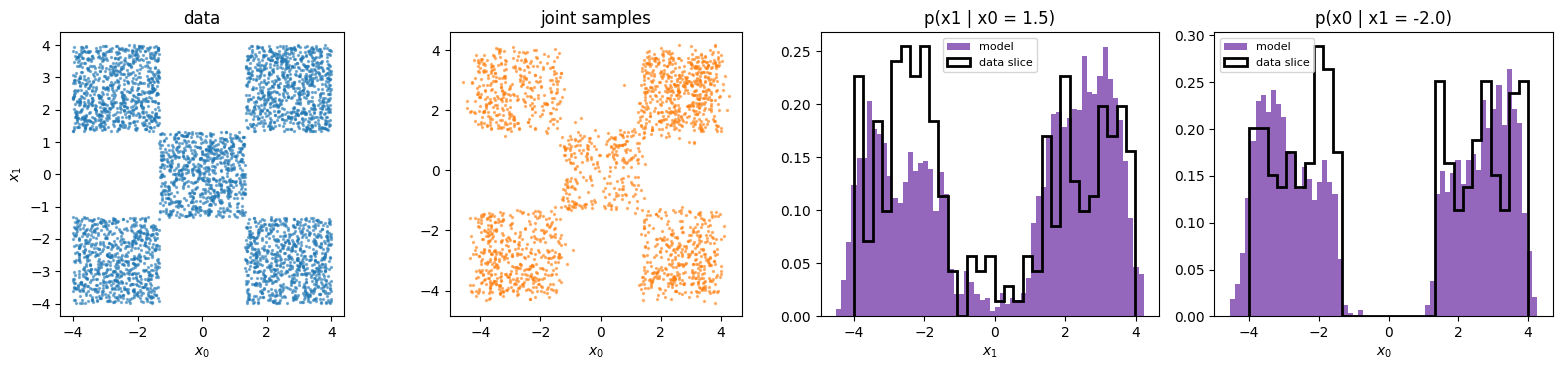

In [5]:
queries = [
    ("p(x1 | x0 = 1.5)", jnp.array([True, False]), jnp.array([[1.5], [0.0]]), 1),
    ("p(x0 | x1 = -2.0)", jnp.array([False, True]), jnp.array([[0.0], [-2.0]]), 0),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
axes[0].scatter(data[:, 0, 0], data[:, 1, 0], s=2, alpha=0.5)
axes[0].set(title="data", xlabel="$x_0$", ylabel="$x_1$")
axes[1].scatter(joint[:, 0, 0], joint[:, 1, 0], s=2, alpha=0.5, color="C1")
axes[1].set(title="joint samples", xlabel="$x_0$")
for ax in axes[:2]:
    ax.set_aspect("equal")

for ax, (title, mask, observed, free) in zip(axes[2:], queries):
    conditional = sample(model, jax.random.key(3), mask, observed, 4000)
    ax.hist(conditional[:, free, 0], bins=60, density=True, color="C4", label="model")

    # Reference: data points whose observed coordinate lands in a thin slice.
    fixed = 1 - free
    nearby = jnp.abs(data[:, fixed, 0] - observed[fixed, 0]) < 0.25
    ax.hist(data[nearby][:, free, 0], bins=30, density=True,
            histtype="step", color="k", lw=2, label="data slice")
    ax.set(title=title, xlabel=f"$x_{free}$")
    ax.legend(fontsize=8)
fig.tight_layout()

Both conditionals are bimodal — at $x_0 = 1.5$ the checkerboard has mass in two bands and
a gap around zero — and the model reproduces that from the same weights that produced the
joint. No retraining, no guidance term, no classifier.

The samples are visibly softer than the data. That is this notebook being sized for a CPU:
6000 steps of a 3-layer transformer on 2 tokens. Longer training sharpens the block edges;
nothing about the method changes.

## Scaling up

The construction does not care that there were two variables. With one token per variable
you can:

- **condition on anything**: parameters given data (a posterior), data given parameters
  (the likelihood), or any subset, all from one model;
- **marginalize** by dropping tokens, using `MarginalizationMask` from
  `probjax.nn.pallas_kernels` so the attention keeps the diagonal and no row becomes fully
  masked (see `examples/nn/nets/attention.ipynb`);
- **encode known structure** by masking attention with the dependency graph, so variables
  that are conditionally independent cannot attend to each other.

## Where to go next

- `examples/nn/nets/attention.ipynb` — the mask objects this builds on.
- `examples/nn/nets/transformer.ipynb` — the denoiser architecture and its `context=` path.
- `diffusion.ipynb` — the plain `EDM` model without the token structure.